### Rossmann Store Sales Analytics:Understanding Performance, Promotion, Customers and Sales Trends

PROJECT OVERVIEW

Rossmann operates over 3000 drug stores in 7 European Countries. In this Project , we are analyzing historical sales data to understand the factors that influence store performance.

In [26]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px
import plotly.graph_objects as go

In [28]:
#load the dataset
train= pd.read_csv('C:/Users/Administrator/Desktop/PYTHON/ROSEMAN SALES ANALYSIS/train.csv')
store = pd.read_csv('C:/Users/Administrator/Desktop/PYTHON/ROSEMAN SALES ANALYSIS/store.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4144\4081211269.py:2: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train= pd.read_csv('C:/Users/Administrator/Desktop/PYTHON/ROSEMAN SALES ANALYSIS/train.csv')


In [29]:
# preview our data
summary_df = pd.DataFrame(
    {
        'Dtaset': ['train.csv', 'store.csv'],
        'Rows': [len(train), len(store)],
        'Columns': [len(train.columns),len(store.columns)],       
    }
)
display(summary_df)
display(summary_df.head())
display(store.head())

,Dtaset,Rows,Columns
0,train.csv,1017209,9
1,store.csv,1115,10


,Dtaset,Rows,Columns
0,train.csv,1017209,9
1,store.csv,1115,10


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [30]:
# data quality audit

def quality_audit(df, name):
    print(f'---Data Quality Audit {name}---')
    
    # Fixed typo: pd.DtaFrame -> pd.DataFrame
    audit = pd.DataFrame({
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df)) * 100,
        'Data types': df.dtypes,
        'Unique Values': df.nunique()
    })
    
    # Filter and sort rows with missing values > 0
    filtered_audit = audit[audit['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
    display(filtered_audit)
    
    print(f"Duplicate Rows: {df.duplicated().sum()}")
    
    # Optional: Return the audit dataframe if you want to assign it to a variable
    return audit

# Calling the function
quality_audit(train, 'Train Data')
quality_audit(store, 'Store Data')
    

---Data Quality Audit Train Data---


,Missing Values,Missing %,Data types,Unique Values


Duplicate Rows: 0
---Data Quality Audit Store Data---


,Missing Values,Missing %,Data types,Unique Values
Promo2SinceYear,544,48.789238,float64,7
Promo2SinceWeek,544,48.789238,float64,24
PromoInterval,544,48.789238,str,3
CompetitionOpenSinceMonth,354,31.748879,float64,12
CompetitionOpenSinceYear,354,31.748879,float64,23
CompetitionDistance,3,0.269058,float64,654


Duplicate Rows: 0


,Missing Values,Missing %,Data types,Unique Values
Store,0,0.000000,int64,1115
StoreType,0,0.000000,str,4
Assortment,0,0.000000,str,3
CompetitionDistance,3,0.269058,float64,654
CompetitionOpenSinceMonth,354,31.748879,float64,12
CompetitionOpenSinceYear,354,31.748879,float64,23
Promo2,0,0.000000,int64,2
Promo2SinceWeek,544,48.789238,float64,24
Promo2SinceYear,544,48.789238,float64,7
PromoInterval,544,48.789238,str,3


#### Data Cleaning

In [31]:
# Convert data to datetime
train['Date']= pd.to_datetime(train['Date'])


In [32]:
# Handle missing competitionDistance(Fill with median competition distance)
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [33]:
 # Handle promo2 missing values
promo2_cols = ['Promo2SinceYear','Promo2SinceWeek','PromoInterval']

for col in promo2_cols:
    store[col] = store[col].fillna(0)
    # store['PromoInterval'] = store['PromoInterval'].fillna(0)

In [34]:
# Handle missing competition open dates
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

## Merging Data Analytical Grain

In [35]:
# record rows before merge
len(train)

1017209

In [36]:
# Perform a left join
df = train.merge(store, on='Store',how='left')



In [37]:
# see the row after merge
len(df)

1017209

In [38]:
# Check unmatched stored
print(f'Unmatched stores:{df['StoreType'].isnull()}')

Unmatched stores:0          False
1          False
2          False
3          False
4          False
           ...  
1017204    False
1017205    False
1017206    False
1017207    False
1017208    False
Name: StoreType, Length: 1017209, dtype: bool


# Featue Engineering

In [39]:
#Time hierachy features
df['Year'] = df['Date'].dt.year
df['Quater'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month_name()
df['WeekofYear'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['DayOfWeek_Name'] = df['Date'] .dt.day_name()

In [40]:
# Business Data Features
df['is_weekend'] = df['DayOfWeek'].isin([6,7]).astype(int)
df['is_Month_Start'] = df['Date'].dt.is_month_start.astype(int)
df['is_Month_End'] = df['Date'].dt.is_month_end.astype(int)

#### Promo, Customer, Store & Competition Features

In [41]:
# Customer Features : Sales per Customer(Avoid division by zero error)
df['Sales Per Customer'] = np.where(df['Customers']>0, df['Sales']/df['Customers'],0)

In [42]:
# Store performance summary
store_summary = df[df['Open'].astype(str) == '1'].groupby('Store').agg(
    Avg_Daily_Sales=('Sales', 'mean'),
    Total_Customer=('Customers', 'sum'),  # Updated to 'sum' for total, or 'mean' if average customers desired[span_3](start_span)[span_3](end_span)
    Avg_Sales_Per_Customer=('Sales Per Customer', 'mean'),  # Fixed: changed 'Customer' to 'Sales Per Customer[span_4](start_span)[span_5](start_span)'[span_4](end_span)[span_5](end_span)
    Promo_Rate=('Promo', 'mean')
).reset_index()

In [43]:
# Rank stores by total sales(REREAD THE CODE)
# Calculate total sales for each open store
total_sales = (
    df[df['Open'] == 1]
    .groupby('Store')['Sales']
    .sum()
)

store_summary['Total_Sales'] = (
    store_summary['Store']
    .map(total_sales)
    .fillna(0)
)

# Rank stores by total sales
store_summary['Rank'] = store_summary['Total_Sales'].rank(
    ascending=False,
    method='min'
).astype(int)

store_summary = store_summary.sort_values('Rank')

 Advanced Time Series and Sales Change Features

In [44]:
# sort by the store and date
df= df.sort_values(by=['Store', 'Date'])

In [45]:
# Calculate 7 day rolling average sales per store
df['7D_Rolling_Sales'] = df.groupby('Store')['Sales'].transform(lambda x: x.rolling(window=7, min_periods=1))

In [46]:
# Calculate day over day percentage change(only for open stores to avoid artificial 100% drops)
df_open = df[df['Open'] == 1] .copy()
df_open['Daily_Sales_Pct_Change'] = df_open.groupby('Store')['Sales'].pct_change()

## Exploratory Data Analysis 

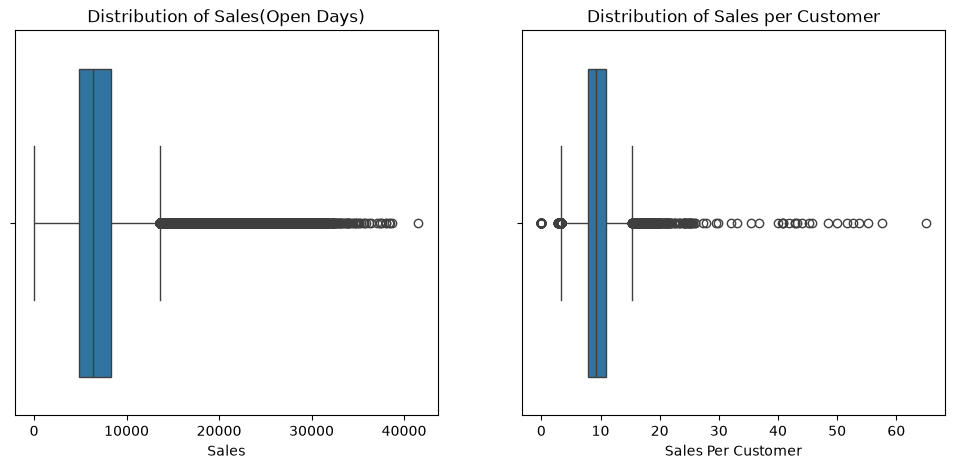

In [47]:
# Outlier Analysis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2,1)
sns.boxplot(x=df_open['Sales'])
plt.title('Distribution of Sales(Open Days)')



plt.subplot(1, 2, 2)
sns.boxplot(x=df_open['Sales Per Customer'])
plt.title('Distribution of Sales per Customer')
plt.savefig('outlieranalysis.png')
plt.show()



1. Both Overall daily sales per customer exhibit a heavy righward skew, characterized by a long tail of high-value outliers extending for beyond upper whiskers.

2. For total daily sales on open days,the central 50% of the data is tightly concentrated , yet the business experience a massive, dense volume of extreme revenue spikes that can push past 40,000.

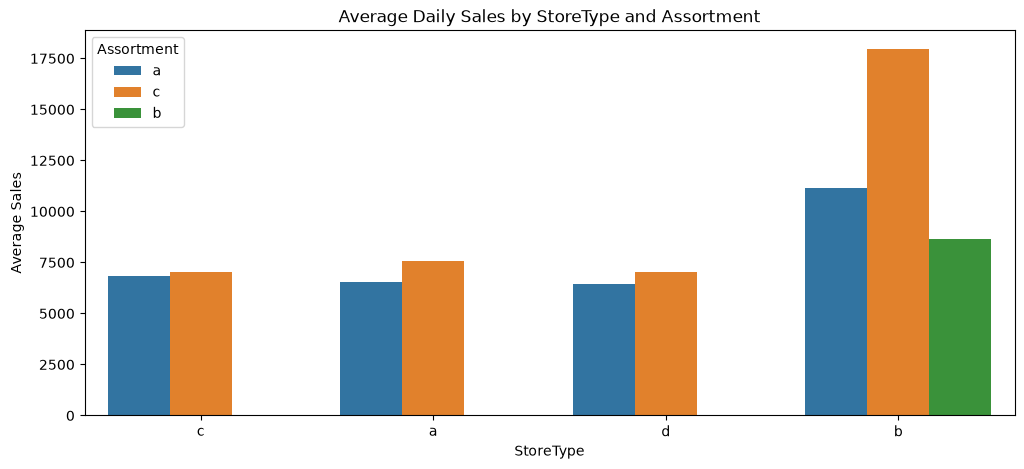

In [48]:
# Which storetypes have different sales pattern
plt.figure(figsize=(12, 5))
sns.barplot(data=df_open,x='StoreType',y='Sales', hue='Assortment',
            errorbar=None, estimator=np.mean)
plt.title('Average Daily Sales by StoreType and Assortment')
plt.ylabel('Average Sales')
plt.savefig('Storetype.png')
plt.show()

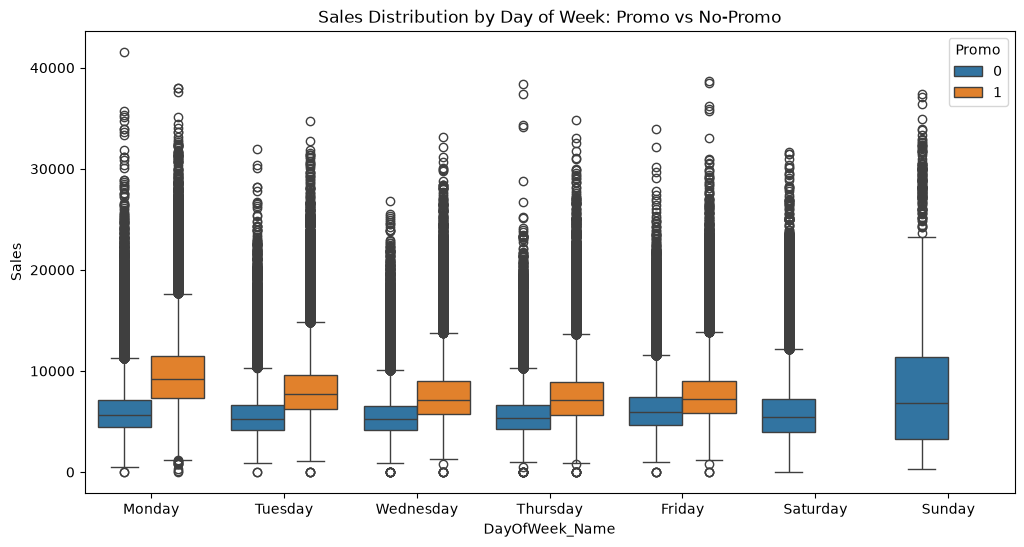

In [49]:
 # How do promotions relate to sales across  different days of the week?
plt.figure(figsize=(12,6))
sns.boxplot(data=df_open, x='DayOfWeek_Name', y='Sales', hue='Promo',
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday']
            )
plt.title('Sales Distribution by Day of Week: Promo vs No-Promo')
plt.savefig('promoanalysis.png')
plt.show()

In [ ]:
#Interactive Visualization (Plotly)
# Aggregate monthly sales across all stores for time-series viewing
monthly_sales = (
    df_open.assign(MonthNum=df_open['Date'].dt.month)
    .groupby(['Year', 'MonthNum'], as_index=False)['Sales']
    .sum()
    .rename(columns={'MonthNum': 'Month'})
    .sort_values(['Year', 'Month'])
)

monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-'+
                                       monthly_sales['Month'].astype(str) + '-01')

fig = px.line(monthly_sales, x='Date', y='Sales',markers=True,
              title = 'Total Rossman Sales Over Time',
              labels = {'Sales':'Total Sales (€)' })
fig.update_layout(hovermode='x unified')
fig.show()

KeyError: 'MonthName'